# Selección de la Mejor Ecuación — Regresión Lineal Múltiple
## Impacto de las Redes Sociales en la Salud Mental de los Adolescentes
**Variable objetivo: `stress_level` (Nivel de estrés 1–10)**

In [1]:
# Tratamiento de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

import statsmodels.stats.api as sms
from statsmodels.compat import lzip
from scipy.stats import pearsonr
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# Configuración matplotlib
plt.rcParams['image.cmap'] = "bwr"
plt.rcParams['savefig.bbox'] = "tight"
style.use('ggplot') or plt.style.use('ggplot')

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Cargando los datos
df = pd.read_excel('datosestresyansiedad.xlsx')
print("-" * 50)
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas\n")
print("-" * 50)
print(df.dtypes)
print("-" * 50)
df.info()
print("-" * 50)
print(df.head())

--------------------------------------------------
Dimensiones: 1200 filas x 13 columnas

--------------------------------------------------
age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
anxiety_level                 int64
addiction_level               int64
depression_label              int64
stress_level                  int64
dtype: object
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 

In [3]:
# Las variables categóricas se convierten en dummy
# Las variables cualitativas entran como cuantitativas (dummies)
df_model = pd.get_dummies(df,
                          columns=['gender', 'platform_usage', 'social_interaction_level'],
                          drop_first=True,
                          dtype=int)
print(df_model.dtypes)
print(df_model.head())

age                                  int64
daily_social_media_hours           float64
sleep_hours                        float64
screen_time_before_sleep           float64
academic_performance               float64
physical_activity                  float64
anxiety_level                        int64
addiction_level                      int64
depression_label                     int64
stress_level                         int64
gender_male                          int64
platform_usage_Instagram             int64
platform_usage_TikTok                int64
social_interaction_level_low         int64
social_interaction_level_medium      int64
dtype: object
   age  daily_social_media_hours  sleep_hours  screen_time_before_sleep  \
0   14                       7.9          7.4                       2.9   
1   19                       1.9          8.0                       2.9   
2   17                       1.3          7.6                       0.5   
3   15                       7.4         

In [4]:
# Observando valores nulos
df_model.isna().sum()

,0
age,0
daily_social_media_hours,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
anxiety_level,0
addiction_level,0
depression_label,0
stress_level,0


## ANÁLISIS EXPLORATORIO (VISUALIZACIÓN)

In [5]:
# Algunas estadísticas descriptivas de nuestros datos
print(df.describe().round(2))

           age  daily_social_media_hours  sleep_hours  \
count  1200.00                   1200.00      1200.00   
mean     15.93                      4.54         6.45   
std       2.02                      2.03         1.44   
min      13.00                      1.00         4.00   
25%      14.00                      2.80         5.20   
50%      16.00                      4.50         6.50   
75%      18.00                      6.30         7.60   
max      19.00                      8.00         9.00   

       screen_time_before_sleep  academic_performance  physical_activity  \
count                   1200.00               1200.00            1200.00   
mean                       1.74                  2.99               1.01   
std                        0.72                  0.58               0.58   
min                        0.50                  2.00               0.00   
25%                        1.10                  2.50               0.50   
50%                        1.8

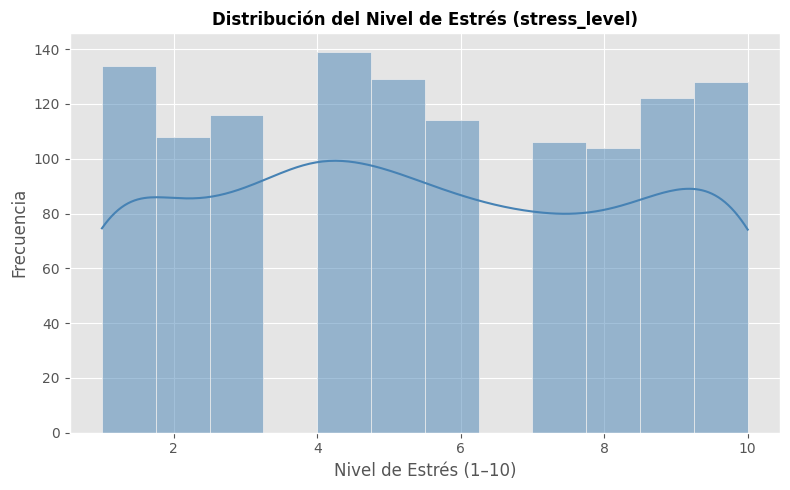

In [6]:
# Distribución de la variable objetivo stress_level
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.histplot(
    data    = df,
    x       = 'stress_level',
    kde     = True,
    color   = 'steelblue',
    ax      = ax
)
ax.set_title('Distribución del Nivel de Estrés (stress_level)', fontsize=12, fontweight='bold')
ax.set_xlabel('Nivel de Estrés (1–10)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

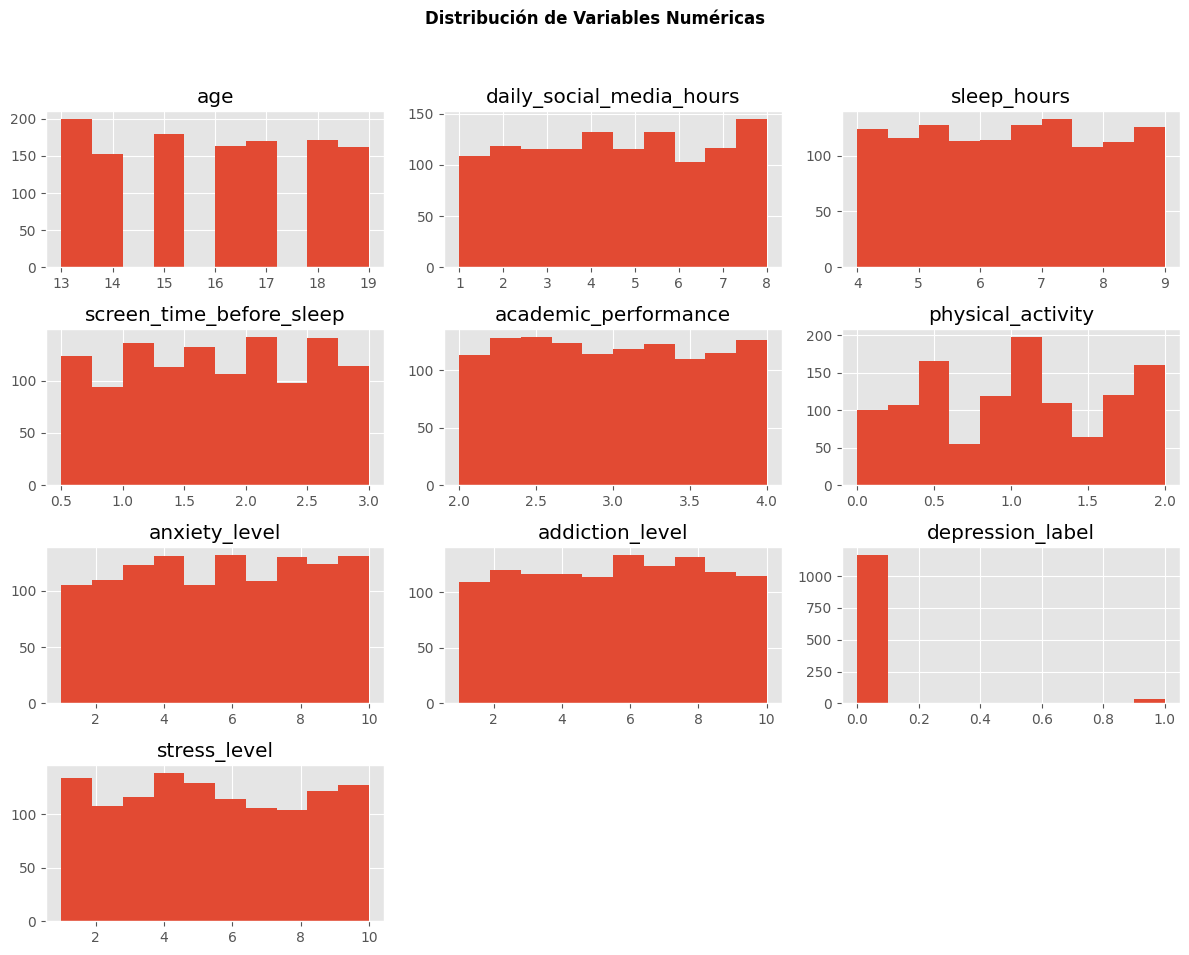

In [7]:
# Distribución de variables numéricas originales
fig = plt.figure(figsize=(12, 10))
df.select_dtypes(include=['float64', 'int64']).hist(ax=fig.gca())
fig.suptitle('Distribución de Variables Numéricas', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Text(0.5, 0.98, 'Distribución variables numéricas')

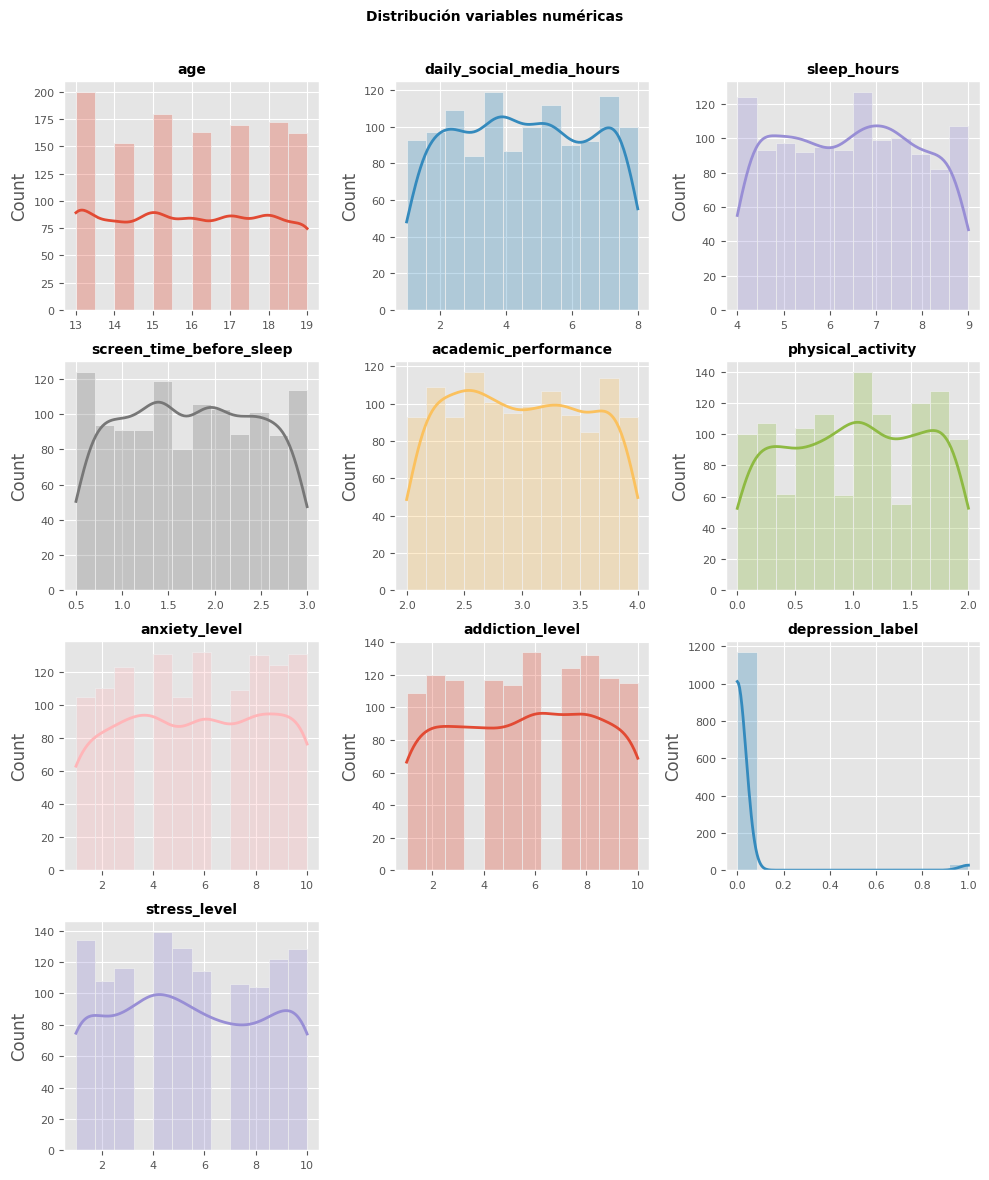

In [8]:
# Gráfico de distribución para cada variable numérica
columnas_numeric = df.select_dtypes(include=['float64', 'int64']).columns
n_cols = 3
n_rows = int(np.ceil(len(columnas_numeric) / n_cols))

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, n_rows * 3))
axes = axes.flat

for i, colum in enumerate(columnas_numeric):
    sns.histplot(
        data     = df,
        x        = colum,
        stat     = "count",
        kde      = True,
        color    = (list(plt.rcParams['axes.prop_cycle']) * 3)[i]["color"],
        line_kws = {'linewidth': 2},
        alpha    = 0.3,
        ax       = axes[i]
    )
    axes[i].set_title(colum, fontsize=10, fontweight='bold')
    axes[i].tick_params(labelsize=8)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
plt.subplots_adjust(top=0.92)
fig.suptitle('Distribución variables numéricas', fontsize=10, fontweight='bold')

### Relación entre variables

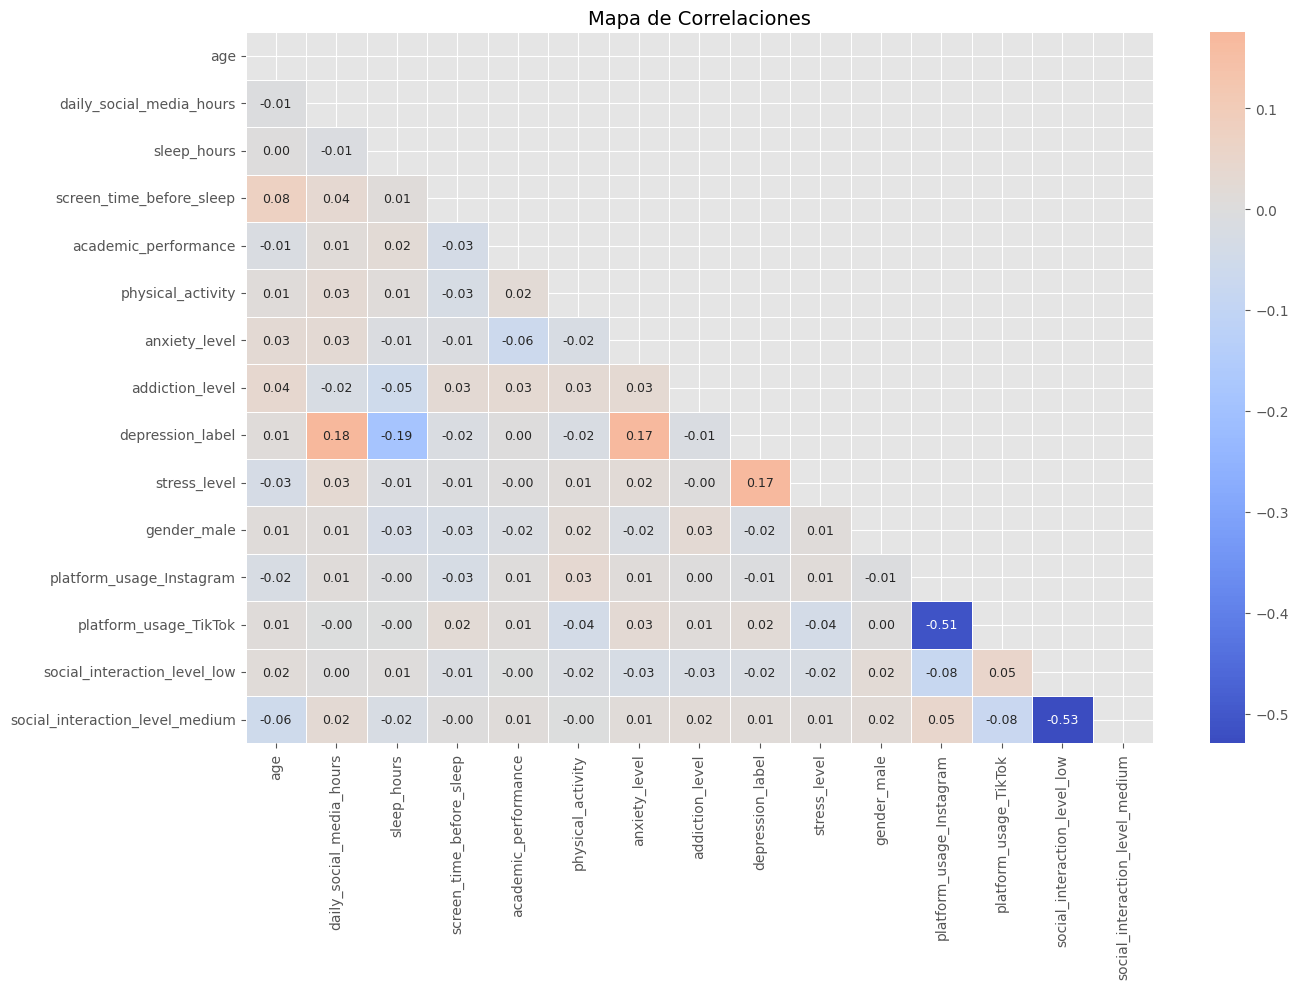

In [9]:
# Mapa de correlaciones
fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df_model.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 9}, ax=ax
)
ax.set_title('Mapa de Correlaciones', fontsize=14)
plt.tight_layout()
plt.savefig('02_correlaciones.png', dpi=150)
plt.show()

In [10]:
# Correlaciones con stress_level ordenadas
print("\n--- Correlación con stress_level ---")
corr_stress = corr_matrix['stress_level'].drop('stress_level').sort_values()
print(corr_stress.round(3))


--- Correlación con stress_level ---
platform_usage_TikTok             -0.038
age                               -0.031
social_interaction_level_low      -0.024
sleep_hours                       -0.011
screen_time_before_sleep          -0.009
academic_performance              -0.001
addiction_level                   -0.000
gender_male                        0.008
social_interaction_level_medium    0.009
physical_activity                  0.012
platform_usage_Instagram           0.013
anxiety_level                      0.016
daily_social_media_hours           0.031
depression_label                   0.170
Name: stress_level, dtype: float64


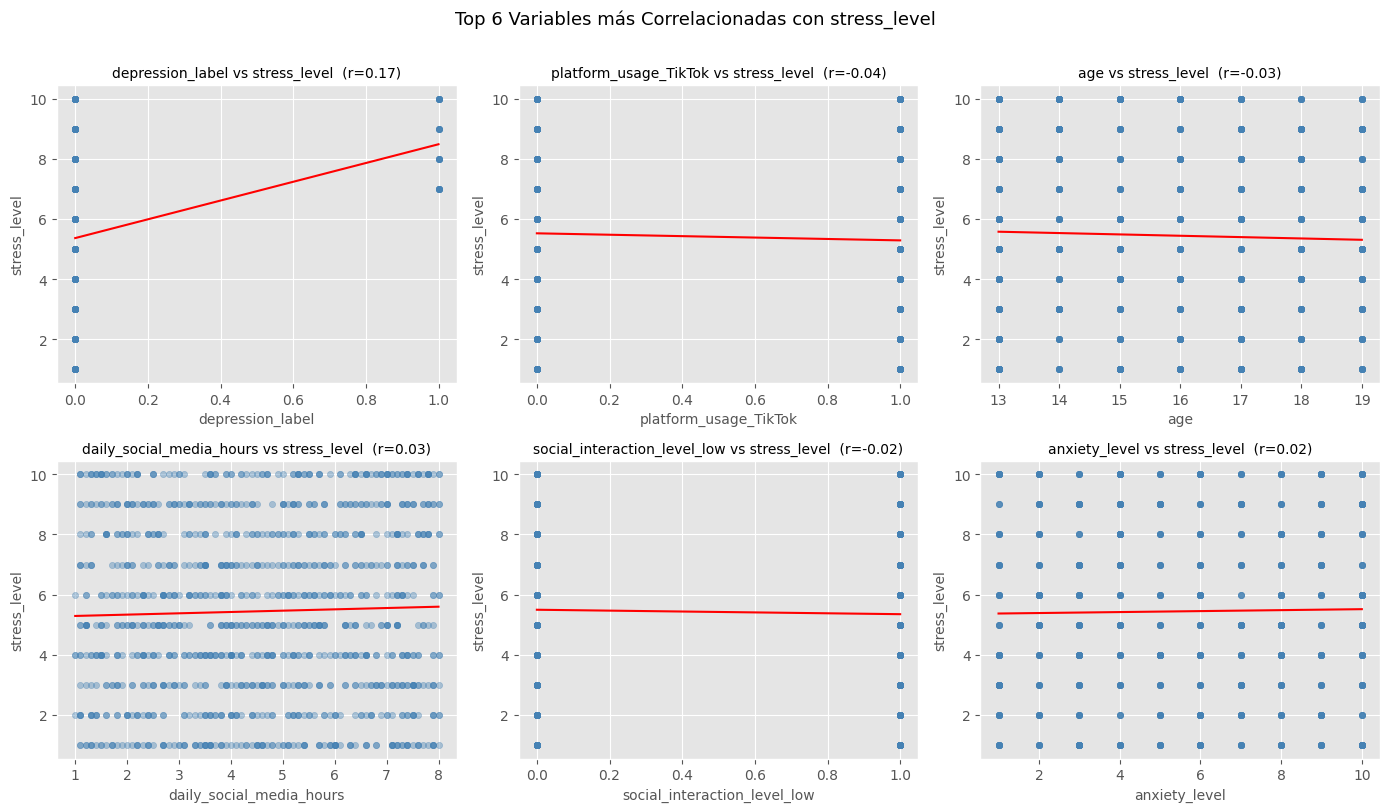

In [11]:
# Scatter plots de las 6 variables más correlacionadas con stress_level
top_vars = corr_stress.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    axes[i].scatter(df_model[var], df_model['stress_level'], alpha=0.4, color='steelblue', s=20)
    m, b = np.polyfit(df_model[var], df_model['stress_level'], 1)
    x_line = np.linspace(df_model[var].min(), df_model[var].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='red', linewidth=1.5)
    axes[i].set_xlabel(var, fontsize=10)
    axes[i].set_ylabel('stress_level', fontsize=10)
    axes[i].set_title(f'{var} vs stress_level  (r={df_model[var].corr(df_model["stress_level"]):.2f})', fontsize=10)

plt.suptitle('Top 6 Variables más Correlacionadas con stress_level', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('03_scatter_top_vars.png', dpi=150)
plt.show()

## PREPARACIÓN DE DATOS Y AJUSTE DEL MODELO

puede usar también:

`X = df_model.drop(columns=['stress_level'])`

`y = df_model['stress_level']`

In [12]:
# Selección de los datos en dependiente e independientes
y = df_model['stress_level']
X = df_model.drop(columns=['stress_level'])

feature_names = X.columns.tolist()
feature_names

['age',
 'daily_social_media_hours',
 'sleep_hours',
 'screen_time_before_sleep',
 'academic_performance',
 'physical_activity',
 'anxiety_level',
 'addiction_level',
 'depression_label',
 'gender_male',
 'platform_usage_Instagram',
 'platform_usage_TikTok',
 'social_interaction_level_low',
 'social_interaction_level_medium']

### Dividiendo la data en entrenamiento (training) 80% y prueba (test) 20%

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size   = 0.8,
    random_state = 42,
    shuffle      = True
)

In [14]:
# Observando los datos
print(f"\nTrain: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")


Train: 960 muestras | Test: 240 muestras


In [15]:
# Escalado de características
# Solo se escalan las variables numéricas continuas; las dummies NO se escalan
num_cols = ['age', 'daily_social_media_hours', 'sleep_hours',
            'screen_time_before_sleep', 'academic_performance',
            'physical_activity', 'anxiety_level', 'addiction_level', 'depression_label']

scaler = StandardScaler()

X_train_sc = X_train.copy().reset_index(drop=True)
X_test_sc  = X_test.copy().reset_index(drop=True)

X_train_sc[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_sc[num_cols]  = scaler.transform(X_test[num_cols])

X_train_sc = pd.DataFrame(X_train_sc, columns=feature_names)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=feature_names)

In [16]:
X_train_sc

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,0.020422,0.766421,1.135845,-0.476546,0.476375,1.029629,-1.598783,-0.553219,-0.163517,0,1,0,1,0
1,-0.469701,0.569455,0.720924,0.915253,-0.268164,0.513021,1.560029,-1.256185,-0.163517,0,1,0,0,1
2,-1.449946,-1.695645,0.444311,0.080173,-0.770295,-0.347993,-0.194867,1.555678,-0.163517,1,0,1,0,0
3,0.020422,0.372490,-1.491985,-0.337366,-0.787610,-1.209007,0.507092,1.555678,6.115554,0,0,1,0,0
4,-0.959824,0.914145,-0.316377,-0.894086,1.411378,-0.175790,-1.247804,-0.904702,-0.163517,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,-1.449946,0.126283,-0.316377,-1.589986,-1.012704,-1.725616,0.156113,1.204195,-0.163517,1,1,0,0,0
956,0.020422,0.126283,1.481612,0.080173,-0.960759,1.201832,0.507092,-0.904702,-0.163517,1,1,0,0,0
957,-1.449946,0.077042,0.236850,-0.476546,1.584527,-0.347993,0.156113,1.204195,-0.163517,0,0,0,0,0
958,-0.469701,-0.513854,-1.353678,1.332793,-0.908814,0.685224,-0.194867,1.555678,-0.163517,1,0,1,1,0


## Entrenar el modelo

In [17]:
def evaluar_modelo(X_tr, X_te, y_tr, y_te, nombre):
    """Entrena y evalúa un modelo lineal, retorna métricas."""
    m = LinearRegression().fit(X_tr, y_tr)
    r2_tr = r2_score(y_tr, m.predict(X_tr))
    r2_te = r2_score(y_te, m.predict(X_te))
    rmse  = np.sqrt(mean_squared_error(y_te, m.predict(X_te)))
    cv    = cross_val_score(m, X_tr, y_tr, cv=5, scoring='r2').mean()
    print(f"  {'Variable(s)':<25} R²Train={r2_tr:.4f} | R²Test={r2_te:.4f} | "
          f"RMSE={rmse:.4f} | CV-R²={cv:.4f}  ← {nombre}")
    return {'Método': nombre, 'R²_Train': r2_tr, 'R²_Test': r2_te,
            'RMSE': rmse, 'CV_R²': cv, 'n_vars': X_tr.shape[1]}

resultados = []

In [18]:
# Modelo base (todas las variables)
print("=" * 75)
print("MODELO BASE — TODAS LAS VARIABLES")
print("=" * 75)
res = evaluar_modelo(X_train_sc, X_test_sc, y_train.reset_index(drop=True),
                     y_test.reset_index(drop=True), f"Todas las variables ({len(feature_names)})")
resultados.append(res)

MODELO BASE — TODAS LAS VARIABLES
  Variable(s)               R²Train=0.0411 | R²Test=-0.0141 | RMSE=2.8042 | CV-R²=0.0058  ← Todas las variables (14)



BLOQUE A — MÉTODOS DE FILTRO

▶ A1. Correlación de Pearson con stress_level
depression_label                   0.178
platform_usage_TikTok              0.047
age                                0.046
social_interaction_level_low       0.038
physical_activity                  0.037
daily_social_media_hours           0.027
social_interaction_level_medium    0.021
academic_performance               0.013
screen_time_before_sleep           0.011
anxiety_level                      0.007
platform_usage_Instagram           0.006
sleep_hours                        0.005
gender_male                        0.005
addiction_level                    0.003

  Variables con |r| ≥ 0.15: ['depression_label']
  Variable(s)               R²Train=0.0316 | R²Test=0.0146 | RMSE=2.7641 | CV-R²=0.0243  ← Pearson |r|≥0.15 (1 vars)


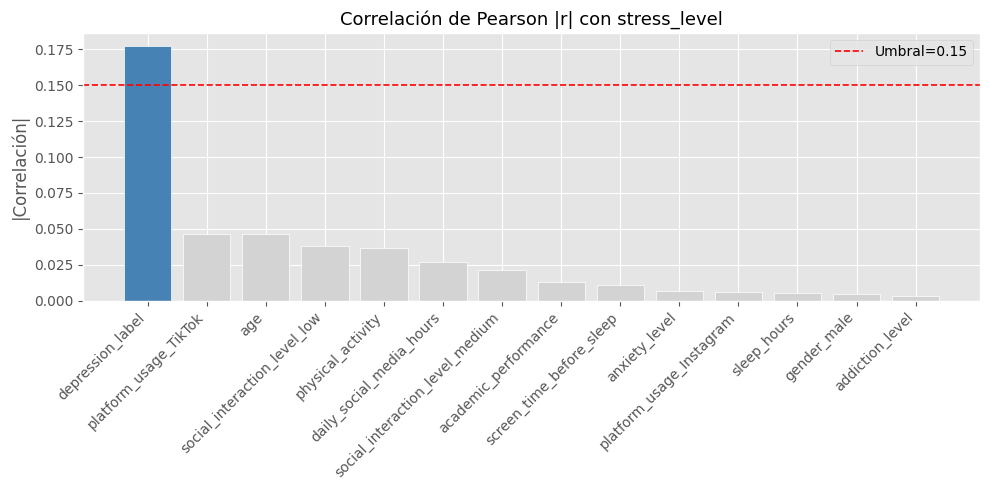

In [19]:
import matplotlib.pyplot as plt

# ============================================================
# BLOQUE A — MÉTODOS DE FILTRO (Filter Methods)
# ============================================================
print("\n" + "=" * 75)
print("BLOQUE A — MÉTODOS DE FILTRO")
print("=" * 75)

# ── A1. Correlación de Pearson ──────────────────────────────
print("\n▶ A1. Correlación de Pearson con stress_level")
y_tr = y_train.reset_index(drop=True)
y_te = y_test.reset_index(drop=True)

corr = X_train_sc.corrwith(y_tr).abs().sort_values(ascending=False)
print(corr.round(3).to_string())

umbral = 0.15 # Se ha bajado el umbral a 0.15 para incluir al menos una variable
vars_pearson = corr[corr >= umbral].index.tolist()
print(f"\n  Variables con |r| ≥ {umbral}: {vars_pearson}")

res = evaluar_modelo(X_train_sc[vars_pearson], X_test_sc[vars_pearson],
                     y_tr, y_te, f"Pearson |r|≥{umbral} ({len(vars_pearson)} vars)")
resultados.append(res)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if v >= umbral else 'lightgray' for v in corr.values]
ax.bar(corr.index, corr.values, color=colors, edgecolor='white')
ax.axhline(umbral, color='red', linestyle='--', linewidth=1.2, label=f'Umbral={umbral}')
ax.set_title('Correlación de Pearson |r| con stress_level', fontsize=13)
ax.set_ylabel('|Correlación|')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('A1_pearson.png', dpi=150)
plt.show()

In [20]:
from sklearn.feature_selection import SelectKBest, f_regression

# ── A2. F-test (ANOVA) ─────────────────────────────────────
print("\n▶ A2. F-test (SelectKBest)")
selector_f = SelectKBest(score_func=f_regression, k='all')
selector_f.fit(X_train_sc, y_tr)

ftest_df = pd.DataFrame({
    'Variable' : feature_names,
    'F-Score'  : selector_f.scores_,
    'p-valor'  : selector_f.pvalues_
}).sort_values('F-Score', ascending=False)
print(ftest_df.round(4).to_string(index=False))

k_f = 8
selector_f_k = SelectKBest(score_func=f_regression, k=k_f).fit(X_train_sc, y_tr)
vars_ftest = [feature_names[i] for i in selector_f_k.get_support(indices=True)]
print(f"\n  Top {k_f} variables por F-test: {vars_ftest}")

res = evaluar_modelo(X_train_sc[vars_ftest], X_test_sc[vars_ftest],
                     y_tr, y_te, f"F-test Top {k_f}")
resultados.append(res)


▶ A2. F-test (SelectKBest)
                       Variable  F-Score  p-valor
               depression_label  31.2437   0.0000
          platform_usage_TikTok   2.0858   0.1490
                            age   2.0529   0.1522
   social_interaction_level_low   1.4068   0.2359
              physical_activity   1.2844   0.2574
       daily_social_media_hours   0.6898   0.4064
social_interaction_level_medium   0.4241   0.5151
           academic_performance   0.1560   0.6930
       screen_time_before_sleep   0.1168   0.7326
                  anxiety_level   0.0443   0.8334
       platform_usage_Instagram   0.0339   0.8539
                    sleep_hours   0.0277   0.8679
                    gender_male   0.0221   0.8818
                addiction_level   0.0086   0.9261

  Top 8 variables por F-test: ['age', 'daily_social_media_hours', 'academic_performance', 'physical_activity', 'depression_label', 'platform_usage_TikTok', 'social_interaction_level_low', 'social_interaction_level_medium'

In [21]:
from sklearn.feature_selection import mutual_info_regression

# ── A3. Información Mutua ──────────────────────────────────
print("\n▶ A3. Información Mutua")
selector_mi = SelectKBest(score_func=mutual_info_regression, k='all')
selector_mi.fit(X_train_sc, y_tr)

mi_df = pd.DataFrame({
    'Variable': feature_names,
    'MI Score': selector_mi.scores_
}).sort_values('MI Score', ascending=False)
print(mi_df.round(4).to_string(index=False))

k_mi = 8
selector_mi_k = SelectKBest(score_func=mutual_info_regression, k=k_mi).fit(X_train_sc, y_tr)
vars_mi = [feature_names[i] for i in selector_mi_k.get_support(indices=True)]
print(f"\n  Top {k_mi} variables por MI: {vars_mi}")

res = evaluar_modelo(X_train_sc[vars_mi], X_test_sc[vars_mi],
                     y_tr, y_te, f"Info Mutua Top {k_mi}")
resultados.append(res)


▶ A3. Información Mutua
                       Variable  MI Score
                            age    0.0234
       daily_social_media_hours    0.0165
               depression_label    0.0161
              physical_activity    0.0126
                  anxiety_level    0.0079
   social_interaction_level_low    0.0059
       screen_time_before_sleep    0.0037
                    sleep_hours    0.0000
           academic_performance    0.0000
                addiction_level    0.0000
                    gender_male    0.0000
       platform_usage_Instagram    0.0000
          platform_usage_TikTok    0.0000
social_interaction_level_medium    0.0000

  Top 8 variables por MI: ['age', 'daily_social_media_hours', 'screen_time_before_sleep', 'physical_activity', 'anxiety_level', 'depression_label', 'gender_male', 'social_interaction_level_medium']
  Variable(s)               R²Train=0.0363 | R²Test=-0.0031 | RMSE=2.7889 | CV-R²=0.0144  ← Info Mutua Top 8


In [22]:
# ── A4. VIF — Eliminación por Multicolinealidad ────────────
print("\n▶ A4. VIF — Eliminación iterativa (umbral VIF < 10)")

def calcular_vif(X_df):
    X_c = sm.add_constant(X_df)
    return pd.DataFrame({
        'Variable': X_df.columns,
        'VIF'     : [variance_inflation_factor(X_c.values, i+1)
                     for i in range(X_df.shape[1])]
    }).sort_values('VIF', ascending=False)

X_vif = X_train_sc.copy()
umbral_vif = 10
iteracion = 1

while True:
    vif_df = calcular_vif(X_vif)
    max_vif = vif_df['VIF'].max()
    if max_vif < umbral_vif:
        break
    var_eliminar = vif_df.iloc[0]['Variable']
    print(f"  Iter {iteracion}: eliminando '{var_eliminar}' (VIF={max_vif:.2f})")
    X_vif = X_vif.drop(columns=[var_eliminar])
    iteracion += 1

vars_vif = X_vif.columns.tolist()
print(f"\n  Variables restantes tras VIF: {vars_vif}")

res = evaluar_modelo(X_train_sc[vars_vif], X_test_sc[vars_vif],
                     y_tr, y_te, f"VIF<{umbral_vif} ({len(vars_vif)} vars)")
resultados.append(res)

# VIF final
print("\n  VIF final:")
print(calcular_vif(X_train_sc[vars_vif]).to_string(index=False))


▶ A4. VIF — Eliminación iterativa (umbral VIF < 10)

  Variables restantes tras VIF: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'anxiety_level', 'addiction_level', 'depression_label', 'gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok', 'social_interaction_level_low', 'social_interaction_level_medium']
  Variable(s)               R²Train=0.0411 | R²Test=-0.0141 | RMSE=2.8042 | CV-R²=0.0058  ← VIF<10 (14 vars)

  VIF final:
                       Variable      VIF
social_interaction_level_medium 1.407239
   social_interaction_level_low 1.397905
          platform_usage_TikTok 1.349063
       platform_usage_Instagram 1.337614
               depression_label 1.111349
                    sleep_hours 1.052322
                  anxiety_level 1.042720
       daily_social_media_hours 1.039065
       screen_time_before_sleep 1.015913
                addiction_level 1.012853
                         

In [23]:
# ============================================================
# BLOQUE B — MÉTODOS WRAPPER
# ============================================================
print("\n" + "=" * 75)
print("BLOQUE B — MÉTODOS WRAPPER")
print("=" * 75)

# ── B1. RFE — Eliminación Recursiva de Características ─────
print("\n▶ B1. RFE (Recursive Feature Elimination)")

from sklearn.feature_selection import RFE

rfe = RFE(estimator=LinearRegression(), n_features_to_select=8)
rfe.fit(X_train_sc, y_tr)

rfe_df = pd.DataFrame({
    'Variable'    : feature_names,
    'Seleccionada': rfe.support_,
    'Ranking'     : rfe.ranking_
}).sort_values('Ranking')
print(rfe_df.to_string(index=False))

vars_rfe = [feature_names[i] for i in range(len(feature_names)) if rfe.support_[i]]
print(f"\n  Variables seleccionadas RFE: {vars_rfe}")

res = evaluar_modelo(X_train_sc[vars_rfe], X_test_sc[vars_rfe],
                     y_tr, y_te, f"RFE (8 vars)")
resultados.append(res)


BLOQUE B — MÉTODOS WRAPPER

▶ B1. RFE (Recursive Feature Elimination)
                       Variable  Seleccionada  Ranking
                            age          True        1
                    sleep_hours          True        1
              physical_activity          True        1
   social_interaction_level_low          True        1
          platform_usage_TikTok          True        1
       platform_usage_Instagram          True        1
                    gender_male          True        1
               depression_label          True        1
                  anxiety_level         False        2
           academic_performance         False        3
                addiction_level         False        4
       screen_time_before_sleep         False        5
       daily_social_media_hours         False        6
social_interaction_level_medium         False        7

  Variables seleccionadas RFE: ['age', 'sleep_hours', 'physical_activity', 'depression_label', 'gender_


▶ B2. RFECV (RFE + Cross-Validation automático)
  Número óptimo de variables: 1
  Variables seleccionadas: ['depression_label']
  Variable(s)               R²Train=0.0316 | R²Test=0.0146 | RMSE=2.7641 | CV-R²=0.0243  ← RFECV (1 vars)


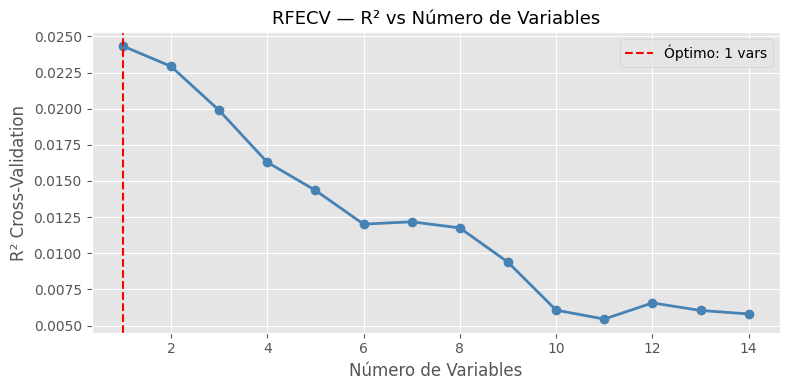

In [24]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold

# ── B2. RFECV — RFE con Cross-Validation ──────────────────
print("\n▶ B2. RFECV (RFE + Cross-Validation automático)")

rfecv = RFECV(
    estimator=LinearRegression(),
    step=1, cv=KFold(5),
    scoring='r2', min_features_to_select=1
)
rfecv.fit(X_train_sc, y_tr)

vars_rfecv = [feature_names[i] for i in range(len(feature_names)) if rfecv.support_[i]]
print(f"  Número óptimo de variables: {rfecv.n_features_}")
print(f"  Variables seleccionadas: {vars_rfecv}")

res = evaluar_modelo(X_train_sc[vars_rfecv], X_test_sc[vars_rfecv],
                     y_tr, y_te, f"RFECV ({rfecv.n_features_} vars)")
resultados.append(res)

# Gráfico RFECV
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
        rfecv.cv_results_['mean_test_score'],
        marker='o', color='steelblue', linewidth=2)
ax.axvline(rfecv.n_features_, color='red', linestyle='--',
           label=f'Óptimo: {rfecv.n_features_} vars')
ax.set_title('RFECV — R² vs Número de Variables', fontsize=13)
ax.set_xlabel('Número de Variables')
ax.set_ylabel('R² Cross-Validation')
ax.legend()
plt.tight_layout()
plt.savefig('B2_rfecv.png', dpi=150)
plt.show()

In [25]:
# B3. Selección Secuencial (Forward / Backward)

In [26]:
from sklearn.feature_selection import SequentialFeatureSelector

# Forward
sfs_fwd = SequentialFeatureSelector(
    LinearRegression(), n_features_to_select='auto',
    direction='forward', scoring='r2', cv=5
)
sfs_fwd.fit(X_train_sc, y_tr)
vars_forward = [feature_names[i] for i in sfs_fwd.get_support(indices=True)]
print(f"  Forward  → {len(vars_forward)} vars: {vars_forward}")

res = evaluar_modelo(X_train_sc[vars_forward], X_test_sc[vars_forward],
                     y_tr, y_te, f"Forward ({len(vars_forward)} vars)")
resultados.append(res)

  Forward  → 7 vars: ['age', 'academic_performance', 'physical_activity', 'anxiety_level', 'depression_label', 'platform_usage_TikTok', 'social_interaction_level_low']
  Variable(s)               R²Train=0.0386 | R²Test=-0.0045 | RMSE=2.7909 | CV-R²=0.0236  ← Forward (7 vars)


In [27]:
# Función de selección forward para modelos lineales de statsmodels

def forward_selection(
    X: pd.DataFrame,
    y: pd.Series,
    criterio: str = 'aic',
    add_constant: bool = True,
    verbose: bool = True
) -> list:

    if add_constant:
        X = sm.add_constant(X, prepend=True).rename(columns={'const': 'intercept'})
    restantes = X.columns.to_list()
    seleccion = []
    if criterio == 'rsquared_adj':
        mejor_metrica = -np.inf
        ultima_metrica = -np.inf
    else:
        mejor_metrica = np.inf
        ultima_metrica = np.inf

    while restantes:
        metricas = []
        for candidata in restantes:
            seleccion_temp = seleccion + [candidata]
            modelo = sm.OLS(endog=y, exog=X[seleccion_temp])
            modelo_res = modelo.fit()
            metrica = getattr(modelo_res, criterio)
            metricas.append(metrica)
        if criterio == 'rsquared_adj':
            mejor_metrica = max(metricas)
            if mejor_metrica > ultima_metrica:
                mejor_variable = restantes[np.argmax(metricas)]
            else:
                break
        else:
            mejor_metrica = min(metricas)
            if mejor_metrica < ultima_metrica:
                mejor_variable = restantes[np.argmin(metricas)]
            else:
                break

        seleccion.append(mejor_variable)
        restantes.remove(mejor_variable)
        ultima_metrica = mejor_metrica

        if verbose:
            print(f'variables: {seleccion} | {criterio}: {mejor_metrica:.3f}')

    return sorted(seleccion)

In [28]:
# Selección de variables método forward con statsmodels
# Las variables dummy ya son numéricas, no se necesita conversión
predictores_fwd = forward_selection(
    X            = X_train_sc,
    y            = y_tr,
    criterio     = 'aic',
    add_constant = False,
    verbose      = True
)
predictores_fwd

variables: ['gender_male'] | aic: 5732.158
variables: ['gender_male', 'platform_usage_Instagram'] | aic: 5593.550
variables: ['gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok'] | aic: 5395.460
variables: ['gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok', 'social_interaction_level_medium'] | aic: 5333.029
variables: ['gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok', 'social_interaction_level_medium', 'social_interaction_level_low'] | aic: 5231.763
variables: ['gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok', 'social_interaction_level_medium', 'social_interaction_level_low', 'depression_label'] | aic: 5209.101
variables: ['gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok', 'social_interaction_level_medium', 'social_interaction_level_low', 'depression_label', 'sleep_hours'] | aic: 5208.098


['depression_label',
 'gender_male',
 'platform_usage_Instagram',
 'platform_usage_TikTok',
 'sleep_hours',
 'social_interaction_level_low',
 'social_interaction_level_medium']

In [29]:
# Backward
sfs_bwd = SequentialFeatureSelector(
    LinearRegression(), n_features_to_select='auto',
    direction='backward', scoring='r2', cv=5
)
sfs_bwd.fit(X_train_sc, y_tr)
vars_backward = [feature_names[i] for i in sfs_bwd.get_support(indices=True)]
print(f"  Backward → {len(vars_backward)} vars: {vars_backward}")

res = evaluar_modelo(X_train_sc[vars_backward], X_test_sc[vars_backward],
                     y_tr, y_te, f"Backward ({len(vars_backward)} vars)")
resultados.append(res)

  Backward → 7 vars: ['age', 'academic_performance', 'physical_activity', 'anxiety_level', 'depression_label', 'platform_usage_TikTok', 'social_interaction_level_low']
  Variable(s)               R²Train=0.0386 | R²Test=-0.0045 | RMSE=2.7909 | CV-R²=0.0236  ← Backward (7 vars)


In [30]:
# Función backward con statsmodels

def backward_selection(
    X: pd.DataFrame,
    y: pd.Series,
    criterio: str = 'aic',
    add_constant: bool = True,
    verbose: bool = True
) -> list:
    if add_constant:
        X = sm.add_constant(X, prepend=True).rename(columns={'const': 'intercept'})

    seleccion = X.columns.to_list()
    modelo = sm.OLS(endog=y, exog=X[seleccion])
    modelo_res = modelo.fit()
    ultima_metrica = getattr(modelo_res, criterio)
    mejor_metrica = ultima_metrica
    if verbose:
        print(f'variables: {seleccion} | {criterio}: {mejor_metrica:.3f}')

    while seleccion:
        metricas = []
        for candidata in seleccion:
            seleccion_temp = seleccion.copy()
            seleccion_temp.remove(candidata)
            modelo = sm.OLS(endog=y, exog=X[seleccion_temp])
            modelo_res = modelo.fit()
            metrica = getattr(modelo_res, criterio)
            metricas.append(metrica)
        if criterio == 'rsquared_adj':
            mejor_metrica = max(metricas)
            if mejor_metrica > ultima_metrica:
                peor_variable = seleccion[np.argmax(metricas)]
            else:
                break
        else:
            mejor_metrica = min(metricas)
            if mejor_metrica < ultima_metrica:
                peor_variable = seleccion[np.argmin(metricas)]
            else:
                break

        seleccion.remove(peor_variable)
        ultima_metrica = mejor_metrica

        if verbose:
            print(f'variables: {seleccion} | {criterio}: {mejor_metrica:.3f}')

    return sorted(seleccion)

In [31]:
# Selección backward con statsmodels
predictores_bwd = backward_selection(
    X            = X_train_sc,
    y            = y_tr,
    criterio     = 'aic',
    add_constant = False,
    verbose      = True
)
predictores_bwd

variables: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'anxiety_level', 'addiction_level', 'depression_label', 'gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok', 'social_interaction_level_low', 'social_interaction_level_medium'] | aic: 5219.014
variables: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'anxiety_level', 'depression_label', 'gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok', 'social_interaction_level_low', 'social_interaction_level_medium'] | aic: 5217.014
variables: ['age', 'daily_social_media_hours', 'sleep_hours', 'academic_performance', 'physical_activity', 'anxiety_level', 'depression_label', 'gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok', 'social_interaction_level_low', 'social_interaction_level_medium'] | aic: 5215.163
variables: ['age', 'sleep_hours', 'acade

['depression_label',
 'gender_male',
 'platform_usage_Instagram',
 'platform_usage_TikTok',
 'sleep_hours',
 'social_interaction_level_low',
 'social_interaction_level_medium']

In [32]:
modelo_final     = sm.OLS(endog=y_tr, exog=X_train_sc[predictores_bwd])
modelo_final_res = modelo_final.fit()
print(modelo_final_res.summary())

                                 OLS Regression Results                                
Dep. Variable:           stress_level   R-squared (uncentered):                   0.654
Model:                            OLS   Adj. R-squared (uncentered):              0.652
Method:                 Least Squares   F-statistic:                              257.9
Date:                Sun, 03 May 2026   Prob (F-statistic):                   6.44e-215
Time:                        22:24:15   Log-Likelihood:                         -2597.0
No. Observations:                 960   AIC:                                      5208.
Df Residuals:                     953   BIC:                                      5242.
Df Model:                           7                                                  
Covariance Type:            nonrobust                                                  
                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------

In [33]:
# Selección de predictores con sklearn SequentialFeatureSelector
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

modelo_skl = LinearRegression()
sfs = SequentialFeatureSelector(
    modelo_skl,
    n_features_to_select = "auto",
    direction            = 'forward',
    scoring              = 'r2',
    cv                   = 5
)
sfs.fit(X_train_sc, y_tr)
sfs.get_feature_names_out().tolist()

['age',
 'academic_performance',
 'physical_activity',
 'anxiety_level',
 'depression_label',
 'platform_usage_TikTok',
 'social_interaction_level_low']


BLOQUE C — MÉTODOS EMBEBIDOS

▶ C1. LASSO con LassoCV (alpha óptimo)
  Alpha óptimo: 0.084861
                       Variable  Coeficiente
               depression_label     0.439426
                            age    -0.049932
              physical_activity     0.029338
                    sleep_hours     0.016917
       screen_time_before_sleep    -0.000000
       daily_social_media_hours     0.000000
           academic_performance    -0.000000
                  anxiety_level    -0.000000
                addiction_level     0.000000
                    gender_male     0.000000
       platform_usage_Instagram     0.000000
          platform_usage_TikTok    -0.000000
   social_interaction_level_low    -0.000000
social_interaction_level_medium     0.000000

  Variables NO eliminadas por LASSO: ['depression_label', 'age', 'physical_activity', 'sleep_hours']
  Variables eliminadas (coef=0): ['screen_time_before_sleep', 'daily_social_media_hours', 'academic_performance', 'anxiety_level

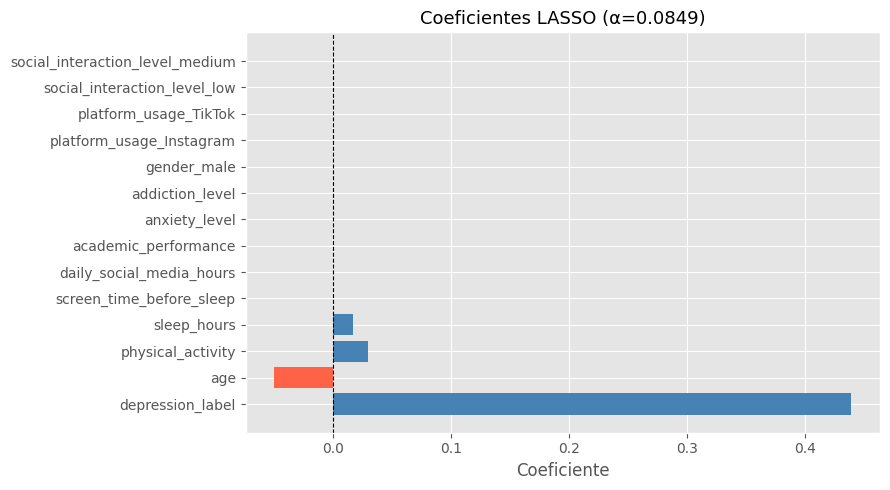

In [34]:
# ============================================================
print("\n" + "=" * 75)
print("BLOQUE C — MÉTODOS EMBEBIDOS")
print("=" * 75)

# ── C1. LASSO (L1) ─────────────────────────────────────────
print("\n▶ C1. LASSO con LassoCV (alpha óptimo)")

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_sc, y_tr)

print(f"  Alpha óptimo: {lasso_cv.alpha_:.6f}")

lasso_coef = pd.DataFrame({
    'Variable'   : feature_names,
    'Coeficiente': lasso_cv.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)
print(lasso_coef.to_string(index=False))

vars_lasso = lasso_coef[lasso_coef['Coeficiente'] != 0]['Variable'].tolist()
print(f"\n  Variables NO eliminadas por LASSO: {vars_lasso}")
print(f"  Variables eliminadas (coef=0): "
      f"{lasso_coef[lasso_coef['Coeficiente'] == 0]['Variable'].tolist()}")

# Evaluar LASSO directamente
y_pred_lasso = lasso_cv.predict(X_test_sc)
r2_lasso  = r2_score(y_te, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_te, y_pred_lasso))
print(f"\n  LASSO → R²Test={r2_lasso:.4f} | RMSE={rmse_lasso:.4f}")
resultados.append({'Método': f'LASSO ({len(vars_lasso)} vars)',
                   'R²_Train': r2_score(y_tr, lasso_cv.predict(X_train_sc)),
                   'R²_Test': r2_lasso, 'RMSE': rmse_lasso,
                   'CV_R²': cross_val_score(lasso_cv, X_train_sc, y_tr, cv=5, scoring='r2').mean(),
                   'n_vars': len(vars_lasso)})

# Gráfico coeficientes LASSO
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tomato' if c < 0 else 'steelblue' if c != 0 else 'lightgray'
          for c in lasso_coef['Coeficiente']]
ax.barh(lasso_coef['Variable'], lasso_coef['Coeficiente'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(f'Coeficientes LASSO (α={lasso_cv.alpha_:.4f})', fontsize=13)
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.savefig('C1_lasso.png', dpi=150)
plt.show()

## BLOQUE C — MÉTODOS EMBEBIDOS (Embedded)

In [35]:
# ── C2. Ridge (L2) — referencia ────────────────────────────
print("\n▶ C2. Ridge con RidgeCV")

ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge_cv.fit(X_train_sc, y_tr)

print(f"  Alpha óptimo: {ridge_cv.alpha_:.4f}")

y_pred_ridge = ridge_cv.predict(X_test_sc)
r2_ridge   = r2_score(y_te, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_te, y_pred_ridge))
print(f"  Ridge → R²Test={r2_ridge:.4f} | RMSE={rmse_ridge:.4f}")
resultados.append({'Método': f'Ridge ({len(feature_names)} vars)',
                   'R²_Train': r2_score(y_tr, ridge_cv.predict(X_train_sc)),
                   'R²_Test': r2_ridge, 'RMSE': rmse_ridge,
                   'CV_R²': cross_val_score(ridge_cv, X_train_sc, y_tr, cv=5, scoring='r2').mean(),
                   'n_vars': len(feature_names)})


▶ C2. Ridge con RidgeCV
  Alpha óptimo: 284.8036
  Ridge → R²Test=-0.0006 | RMSE=2.7853


In [36]:
# ── C3. Statsmodels — p-valores (eliminación manual) ───────
print("\n▶ C3. Eliminación por p-valor (Statsmodels, α=0.05)")

X_sm    = X_train_sc.copy()
vars_sm = feature_names.copy()
iteracion = 1

while True:
    X_iter = sm.add_constant(X_sm[vars_sm])
    modelo = sm.OLS(y_tr, X_iter).fit()
    pvals  = modelo.pvalues.drop('const')
    max_p  = pvals.max()
    if max_p < 0.05:
        break
    var_out = pvals.idxmax()
    print(f"  Iter {iteracion}: eliminando '{var_out}' (p={max_p:.4f})")
    vars_sm.remove(var_out)
    iteracion += 1

print(f"\n  Variables finales (p<0.05): {vars_sm}")
res = evaluar_modelo(X_train_sc[vars_sm], X_test_sc[vars_sm],
                     y_tr, y_te, f"p-valor<0.05 ({len(vars_sm)} vars)")
resultados.append(res)


▶ C3. Eliminación por p-valor (Statsmodels, α=0.05)
  Iter 1: eliminando 'social_interaction_level_medium' (p=0.9414)
  Iter 2: eliminando 'daily_social_media_hours' (p=0.8318)
  Iter 3: eliminando 'screen_time_before_sleep' (p=0.8219)
  Iter 4: eliminando 'addiction_level' (p=0.7909)
  Iter 5: eliminando 'gender_male' (p=0.7271)
  Iter 6: eliminando 'academic_performance' (p=0.6460)
  Iter 7: eliminando 'platform_usage_Instagram' (p=0.5184)
  Iter 8: eliminando 'anxiety_level' (p=0.4596)
  Iter 9: eliminando 'social_interaction_level_low' (p=0.3113)
  Iter 10: eliminando 'physical_activity' (p=0.2396)
  Iter 11: eliminando 'sleep_hours' (p=0.1949)
  Iter 12: eliminando 'platform_usage_TikTok' (p=0.1785)
  Iter 13: eliminando 'age' (p=0.1507)

  Variables finales (p<0.05): ['depression_label']
  Variable(s)               R²Train=0.0316 | R²Test=0.0146 | RMSE=2.7641 | CV-R²=0.0243  ← p-valor<0.05 (1 vars)



COMPARACIÓN FINAL — TODOS LOS MÉTODOS
                   Método  R²_Train  R²_Test   RMSE  CV_R²  n_vars
Pearson |r|≥0.15 (1 vars)    0.0316   0.0146 2.7641 0.0243       1
           RFECV (1 vars)    0.0316   0.0146 2.7641 0.0243       1
    p-valor<0.05 (1 vars)    0.0316   0.0146 2.7641 0.0243       1
           LASSO (4 vars)    0.0331   0.0126 2.7670 0.0215       4
          Ridge (14 vars)    0.0375  -0.0006 2.7853 0.0133      14
             F-test Top 8    0.0382  -0.0024 2.7879 0.0171       8
         Info Mutua Top 8    0.0363  -0.0031 2.7889 0.0144       8
         Forward (7 vars)    0.0386  -0.0045 2.7909 0.0236       7
        Backward (7 vars)    0.0386  -0.0045 2.7909 0.0236       7
             RFE (8 vars)    0.0402  -0.0093 2.7974 0.0190       8
 Todas las variables (14)    0.0411  -0.0141 2.8042 0.0058      14
         VIF<10 (14 vars)    0.0411  -0.0141 2.8042 0.0058      14


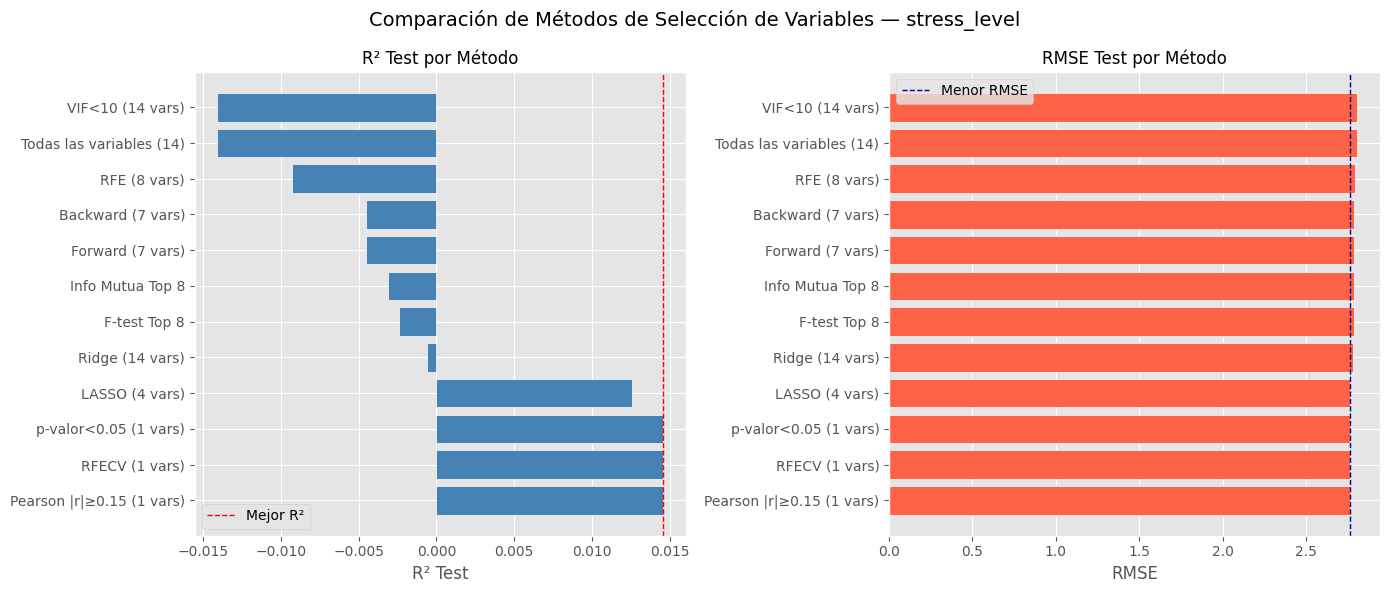


  🏆 Mejor método : Pearson |r|≥0.15 (1 vars)
     R² Test      : 0.0146
     RMSE         : 2.7641
     CV R²        : 0.0243
     N° variables : 1


In [37]:
# ============================================================
# BLOQUE D — COMPARACIÓN FINAL DE TODOS LOS MÉTODOS
# ============================================================
print("\n" + "=" * 75)
print("COMPARACIÓN FINAL — TODOS LOS MÉTODOS")
print("=" * 75)

resumen_df = pd.DataFrame(resultados)
resumen_df = resumen_df.sort_values('R²_Test', ascending=False)
resumen_df[['R²_Train', 'R²_Test', 'RMSE', 'CV_R²']] = \
    resumen_df[['R²_Train', 'R²_Test', 'RMSE', 'CV_R²']].round(4)

print(resumen_df.to_string(index=False))

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# R² Test
axes[0].barh(resumen_df['Método'], resumen_df['R²_Test'],
             color='steelblue', edgecolor='white')
axes[0].axvline(resumen_df['R²_Test'].max(), color='red',
                linestyle='--', linewidth=1, label='Mejor R²')
axes[0].set_title('R² Test por Método', fontsize=12)
axes[0].set_xlabel('R² Test')
axes[0].legend()

# RMSE
axes[1].barh(resumen_df['Método'], resumen_df['RMSE'],
             color='tomato', edgecolor='white')
axes[1].axvline(resumen_df['RMSE'].min(), color='navy',
                linestyle='--', linewidth=1, label='Menor RMSE')
axes[1].set_title('RMSE Test por Método', fontsize=12)
axes[1].set_xlabel('RMSE')
axes[1].legend()

plt.suptitle('Comparación de Métodos de Selección de Variables — stress_level', fontsize=14)
plt.tight_layout()
plt.savefig('D_comparacion_final.png', dpi=150)
plt.show()

# ── Mejor método ───────────────────────────────────────────
mejor = resumen_df.iloc[0]
print(f"\n  🏆 Mejor método : {mejor['Método']}")
print(f"     R² Test      : {mejor['R²_Test']}")
print(f"     RMSE         : {mejor['RMSE']}")
print(f"     CV R²        : {mejor['CV_R²']}")
print(f"     N° variables : {int(mejor['n_vars'])}")

---

## Selección de variables usando Random Forest

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 8

import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.model_selection import RepeatedKFold, GridSearchCV
from sklearn.inspection import permutation_importance

! pip install optuna -q
import optuna
import warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"Versión de scikit-learn: {sklearn.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.4 MB/s eta 0:00:00
Versión de scikit-learn: 1.6.1


In [39]:
# Cargando los datos nuevamente para Random Forest (sin escalar)
df_rf = pd.read_excel('datosestresyansiedad.xlsx')
df_rf = pd.get_dummies(df_rf,
                       columns=['gender', 'platform_usage', 'social_interaction_level'],
                       drop_first=True, dtype=int)
display(df_rf.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1200 non-null   int64  
 1   daily_social_media_hours         1200 non-null   float64
 2   sleep_hours                      1200 non-null   float64
 3   screen_time_before_sleep         1200 non-null   float64
 4   academic_performance             1200 non-null   float64
 5   physical_activity                1200 non-null   float64
 6   anxiety_level                    1200 non-null   int64  
 7   addiction_level                  1200 non-null   int64  
 8   depression_label                 1200 non-null   int64  
 9   stress_level                     1200 non-null   int64  
 10  gender_male                      1200 non-null   int64  
 11  platform_usage_Instagram         1200 non-null   int64  
 12  platform_usage_TikTo

None

In [40]:
# División de los datos en entrenamiento y test
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    df_rf.drop(columns='stress_level'),
    df_rf['stress_level'],
    test_size    = 0.25,
    random_state = 123
)

print(f"Tamaño conjunto entrenamiento: {X_train_rf.shape[0]}")
print(f"Tamaño conjunto test         : {X_test_rf.shape[0]}")

# Creación del modelo Random Forest
modelo_rf = RandomForestRegressor(
    n_estimators = 10,
    criterion    = 'squared_error',
    max_depth    = None,
    max_features = 1,
    oob_score    = False,
    n_jobs       = -1,
    random_state = 123
)

# Entrenamiento del modelo
modelo_rf.fit(X_train_rf, y_train_rf)

Tamaño conjunto entrenamiento: 900
Tamaño conjunto test         : 300


RandomForestRegressor(max_features=1, n_estimators=10, n_jobs=-1,
                      random_state=123)

In [41]:
# Error de test del modelo inicial Random Forest
predicciones_rf = modelo_rf.predict(X_test_rf)
mse_rf  = mean_squared_error(y_true=y_test_rf, y_pred=predicciones_rf)
rmse_rf = np.sqrt(mse_rf)
print(f"\nEl error (RMSE) de test es: {rmse_rf:.4f}")


El error (RMSE) de test es: 3.1165


### Optimización de hiperparámetros

In [42]:
# Importancia de los predictores en el modelo Random Forest
importancia_predictores = pd.DataFrame({
    'predictor'  : X_train_rf.columns,
    'importancia': modelo_rf.feature_importances_
})
print("Importancia de los predictores en el modelo")
print("-------------------------------------------")
importancia_predictores.sort_values('importancia', ascending=False)

Importancia de los predictores en el modelo
-------------------------------------------


,predictor,importancia
1,daily_social_media_hours,0.135450
2,sleep_hours,0.133694
4,academic_performance,0.130661
5,physical_activity,0.111897
3,screen_time_before_sleep,0.111895
6,anxiety_level,0.096659
7,addiction_level,0.087341
0,age,0.082353
9,gender_male,0.026554
13,social_interaction_level_medium,0.020734


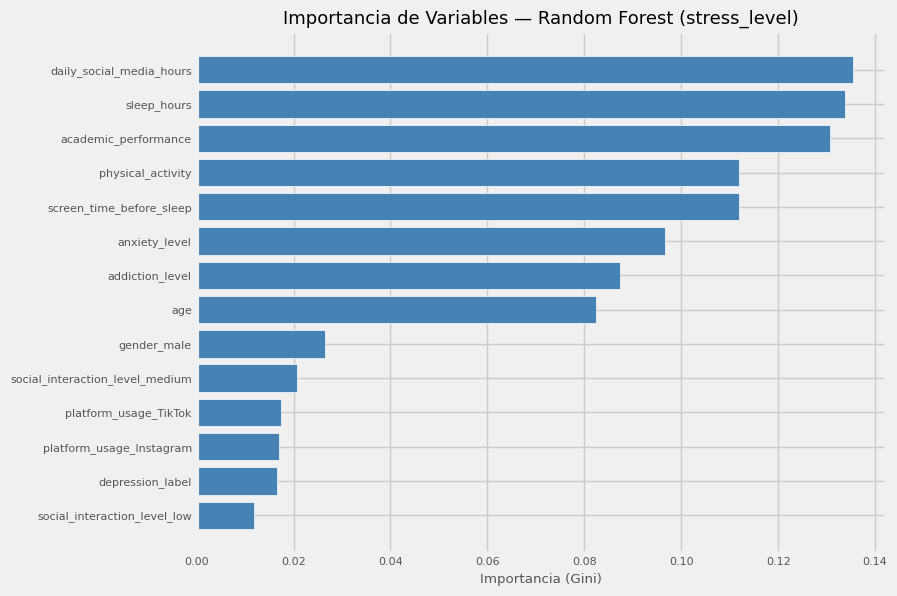

In [43]:
# Gráfico de importancia de variables — Random Forest
imp_sorted = importancia_predictores.sort_values('importancia', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_sorted['predictor'], imp_sorted['importancia'],
        color='steelblue', edgecolor='white')
ax.set_title('Importancia de Variables — Random Forest (stress_level)', fontsize=13)
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.savefig('RF_importancia.png', dpi=150)
plt.show()

In [44]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc

!jupyter nbconvert --to pdf "RLM_mejor_ecuacion_estres.ipynb"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f